# Detection & Analysis of Pre-SN Outburst Simulations

[View our paper here](https://iopscience.iop.org/article/10.3847/1538-4357/ad973d) for details on our cleaning and binning method, as well as our pre-SN outburst detection process!

## Settings 
### Load the config file and preset column names

In [1]:
# ==== User Settings ====

# Enter the config file name:
CONFIG_FILE = "config.ini"

# Enter the column name preset to use 
# (see config file for more; options: "atlas", "rubin", "tess"):
PRESET = "atlas"

# =======================

import sys
import numpy as np
import pandas as pd
from typing import Optional, List
import matplotlib.pyplot as plt

from download import load_config, make_dir_if_not_exists
from lightcurve import PresetColumnNames, Supernova, AveragedSupernova, LightCurve, SimDetecLightCurve, SimDetecSupernova
from plot import Plot, PlotLimits
from utils import reformat_dir, get_config_flags, get_inverse_mjd_ranges, hexstring_to_int, TEMPLATE_CHANGE_1_MJD, TEMPLATE_CHANGE_2_MJD
from generate_detec_table import ContaminationTable, Model, SimDetecTable, SimDetecTables, EfficiencyTable, AtlasSimDetecLoop

# load config
config = load_config(CONFIG_FILE)

# load preset
print(f"\nLoading {PRESET} preset column names from {CONFIG_FILE}...")
colnames = PresetColumnNames(config, PRESET)
print(colnames.__str__())


Loading config file at config.ini...

Loading atlas preset column names from config.ini...
--- Required Columns ---
mjd: MJD
flux: uJy
dflux: duJy
--- Optional Columns ---
chisquare: chi/N
filt: F
mag: m
dmag: dm
ra: RA
dec: Dec
--- Extra Columns to Copy ---
x, y, maj, min, phi, apfit, mag5sig, Sky, Obs


### Load the light curves

In [2]:
# ==== User Settings ====

# Enter the target SN name:
TNSNAME = '2019vxm'

# Enter the path to the data directory that contains the ATClean-readable SN directories:
INPUT_DIR = config["dir"]["atclean_input"]

# Enter the path to the directory that contains cleaned and binned light curves, plots, and more:
OUTPUT_DIR = config["dir"]["output"]

# Automatically save the generated plots in this notebook?:
SAVE_PLOTS = False
# Enter the path to a directory to optionally save plots:
PLOTS_DIR = f'{OUTPUT_DIR}/{TNSNAME}/bump_analysis/plots'

# Enter the filter for this light curve:
FILT = 'o'

# Enter the SN's discovery date:
DISCOVERY_DATE = 58650.0

# Enter the size of the MJD bins (in days):
MJD_BIN_SIZE = 1.0

# Enter the number of control light curves to load:
NUM_CONTROLS = 7 #int(config["download"]["num_controls"])

# =======================

# make sure tnsname not attached to end of input and output dirs
INPUT_DIR = reformat_dir(INPUT_DIR, TNSNAME)
OUTPUT_DIR = reformat_dir(OUTPUT_DIR, TNSNAME)

print(f'SN {TNSNAME}, filter {FILT}', end='')
if not DISCOVERY_DATE is None:
    print(f', discovery date: {DISCOVERY_DATE}')
print(f'Output directory (load cleaned and binned light curves): {OUTPUT_DIR}/{TNSNAME}')
print(f'Plots directory (save plots): {PLOTS_DIR}')

# load cleaned light curves
sn = Supernova(colnames, tnsname=TNSNAME, mjd0=DISCOVERY_DATE, filt=FILT)
sn.load_all(OUTPUT_DIR, NUM_CONTROLS, cleaned=True)

# load binned light curves
avg_sn = SimDetecSupernova(colnames, tnsname=TNSNAME, mjdbinsize=MJD_BIN_SIZE, mjd0=DISCOVERY_DATE, filt=FILT)
avg_sn.load_all(OUTPUT_DIR, NUM_CONTROLS)

p = Plot(PLOTS_DIR)

config_flags = get_config_flags(config)

SN 2019vxm, filter o, discovery date: 58650.0
Output directory (load cleaned and binned light curves): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm
Plots directory (save plots): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm/bump_analysis/plots

Loading SN light curve and 7 control light curves...
could not read /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm/controls/2019vxm_i001.o.clean.lc.txt!
Could not load control light curve 1; skipping...
Successfully loaded SN light curve and 7 control light curves (control indices: [2, 3, 4, 5, 6, 7, 8])
Updating column names for all light curves in this Supernova object (key: dflux_new, name: duJy_new)...

Loading averaged SN light curve and 7 averaged control light curves...
could not read /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2019vxm/controls/2019vxm_i001.o.1.00days.lc.txt!
Could not load averaged control light curve 1; skipping...
Successfully loa

## Plot cleaned original and binned pre-SN light curves

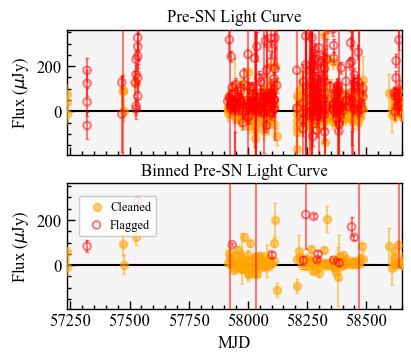

In [3]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_preSN(
    sn, 
    avg_sn, 
    config_flags,
    custom_lims=custom_lims,
    save=SAVE_PLOTS
)

## Plot all control light curves

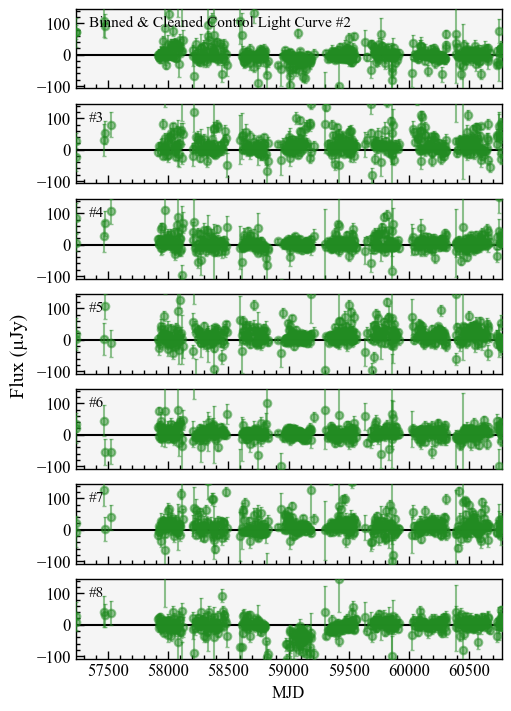

In [4]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_all_controls(
    avg_sn, 
    config_flags,
    custom_lims=custom_lims,
    two_columns=False,
    save=SAVE_PLOTS
)

## Plot binned pre-SN and control light curve

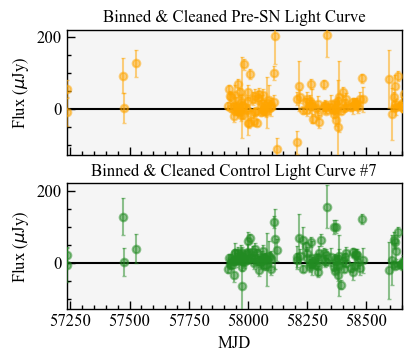

In [5]:
# ==== User Settings ====

# Enter the index of the control light curve to plot:
SELECT_CONTROL_INDEX = 7

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_binned_examples(
    avg_sn, 
    SELECT_CONTROL_INDEX, 
    config_flags,
    custom_lims=custom_lims, 
    save=SAVE_PLOTS
)

## Get detection limits w.r.t. contamination

We use the bisection method to calculate the best detection limits $\Sigma_{\text{FOM, limit}}$ for each $\sigma_{\text{kernel}}$ with respect to a target contamination value.

We measure contamination for a given $\sigma_{\text{kernel}}$ and its corresponding $\Sigma_{\text{FOM, limit}}$ by counting the number of false positives in the control light curves (where a single false positive is defined by a continuous sequence of $\Sigma_{\text{FOM}}$ above $\Sigma_{\text{FOM, limit}}$). We record two alternative measures of contamination for evaluating a certain $\Sigma_{\text{FOM, limit}}$:

1. the number of positive control light curves (default option)
2. the total number of false positives throughout all control light curve

#### Plot observation seasons

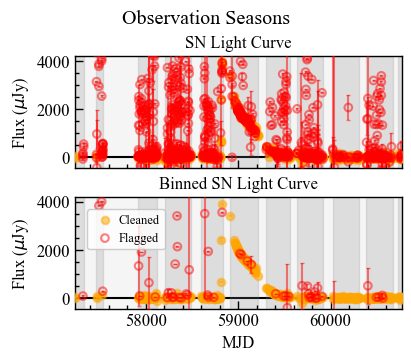

In [6]:
# ==== User Settings ====

# List the observation seasons 
# (set to empty list [] for the entire span of the light curve):
MJD_RANGES: List[List[int]] = [
    [57233, 57329], 
    [57466, 57536], 
    [57914, 58123],
    [58206, 58487],
    [58594, 58837],
    [58910, 59213],
    [59304, 59565],
    [59637, 59916],
    [60023, 60310],
    [60387, 60672],
    [60727, 60771]
]

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

if MJD_RANGES is None or len(MJD_RANGES) < 1:
    min_mjd, max_mjd = avg_sn.lcs[0].get_min_and_max_mjd()
    print(f"Setting MJD ranges to (min MJD {min_mjd}, max MJD {max_mjd})")
    MJD_RANGES = [[min_mjd, max_mjd]]

fig = p.plot_mjd_ranges(
    sn, 
    avg_sn, 
    config_flags,
    MJD_RANGES,
    suptitle="Observation Seasons",
    custom_lims=custom_lims,
    filename="observation_seasons",
    save=SAVE_PLOTS
)

### Exclude bad MJD ranges and determine valid observation seasons

Min MJD: 57233.0, max MJD: 60770.0
Observation season ranges: [[57233, 57329], [57466, 57536], [57914, 58123], [58206, 58487], [58594, 58837], [58910, 59213], [59304, 59565], [59637, 59916], [60023, 60310], [60387, 60672], [60727, 60771]]
Excluding additional MJD ranges [[57233.0, 58417], [58882, 60771.0]]...
Excluded MJD ranges (observation season gaps plus expanded edges and additional excluded ranges): 
	[[57233.0, 58417], [58488, 58593], [58838, 60771.0]]
Included ranges: 
	[[58418, 58487], [58594, 58837]]


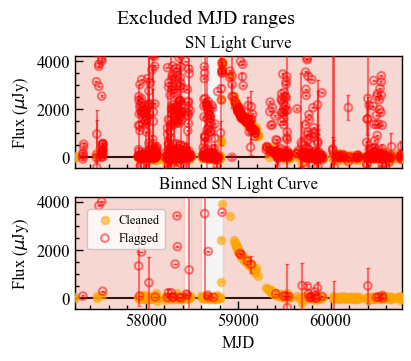

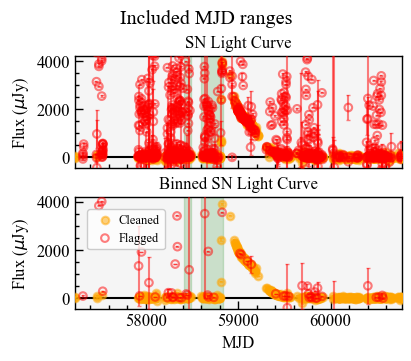

In [7]:
# ==== User Settings ====

# Optionally expand observation gap MJD ranges by +-exclude_obs_edges days on either side 
# (set to None or 0 to skip):
EXPAND_EDGES = 0

# Optionally exclude additional bad observation seasons or arbitrary ranges 
# (set to None or empty list [] to skip):
EXCLUDE_MJD_RANGES: List[List[int]] = [
    [57233.0, TEMPLATE_CHANGE_1_MJD],
    [TEMPLATE_CHANGE_2_MJD, 60771.0]
]

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

min_mjd, max_mjd = avg_sn.lcs[0].get_min_and_max_mjd()
print(f'Min MJD: {min_mjd}, max MJD: {max_mjd}')

print(f'Observation season ranges: {MJD_RANGES}')

excluded_mjd_ranges = get_inverse_mjd_ranges(
    MJD_RANGES, 
    min_mjd, 
    max_mjd, 
    expand_edges=EXPAND_EDGES,
    exclude_mjd_ranges=EXCLUDE_MJD_RANGES
)
print(f'Excluded MJD ranges (observation season gaps plus expanded edges and additional excluded ranges): \n\t{excluded_mjd_ranges}')

included_mjd_ranges = get_inverse_mjd_ranges(
    excluded_mjd_ranges, 
    min_mjd, 
    max_mjd
)
print(f"Included ranges: \n\t{included_mjd_ranges}")

custom_lims = PlotLimits(
    xlower=XLIM_LOWER,
    xupper=XLIM_UPPER,
    ylower=YLIM_LOWER,
    yupper=YLIM_UPPER,
)

fig = p.plot_mjd_ranges(
    sn, 
    avg_sn, 
    config_flags,
    excluded_mjd_ranges,
    suptitle="Excluded MJD ranges",
    range_color="tomato",
    custom_lims=custom_lims,
    filename="excluded_mjd_ranges",
    save=SAVE_PLOTS
)

fig = p.plot_mjd_ranges(
    sn, 
    avg_sn, 
    config_flags,
    included_mjd_ranges,
    suptitle="Included MJD ranges",
    range_color="forestgreen",
    custom_lims=custom_lims,
    filename="included_mjd_ranges",
    save=SAVE_PLOTS
)

### Calculate the preliminary range of valid detection limits $\Sigma_{\text{FOM, limit}}$

As our starting range of valid detection limits $\Sigma_{\text{FOM, limit}}$ for each $\sigma_{\text{kernel}}$, we set our lower limit to 0 and our upper limit to the maximum $\Sigma_{\text{FOM}}$ value across all control light curves.

In [8]:
# ==== User Settings ====

# Enter possible sigma kernels of the weighted gaussian rolling sum:
SIGMA_KERNS = [1, 2, 3, 4, 5]
#list(np.logspace(np.log(0.125) / np.log(10), np.log(4) / np.log(10), num=5, base=10))

# Exclude certain control lcs from the analysis 
# (set to None or empty list [] for no exclusions):
SKIP_CONTROL_INDICES = [2, 8]

# Optionally, manually enter the x and y limits for the plot:
XLIM_LOWER = None
XLIM_UPPER = None
YLIM_LOWER = None
YLIM_UPPER = None

# =======================

print(f"Skipping control light curves: {SKIP_CONTROL_INDICES}")
avg_sn.remove_lc_indices(SKIP_CONTROL_INDICES)

print(f"Calculating preliminary FOM limit ranges for sigma_kerns {SIGMA_KERNS}")
# avg_sn.set_mjd_ranges(included_mjd_ranges)
# print(avg_sn.lc_indices)
# avg_sn.lcs[3].apply_rolling_sum(0.5)
# print(avg_sn.lcs[3].t[['MJD',avg_sn.colnames.flux,avg_sn.colnames.snrsumnorm]].to_string())
# sys.exit()
all_fom_dict, prelim_fom_limit_ranges = avg_sn.get_prelim_fom_limit_ranges(
    SIGMA_KERNS,
    included_mjd_ranges,
)

Skipping control light curves: [2, 8]
Calculating preliminary FOM limit ranges for sigma_kerns [1, 2, 3, 4, 5]
Getting preliminary valid FOM limit ranges...
Getting all control FOM for MJD ranges [[58418, 58487], [58594, 58837]]...
Valid FOM limit ranges: {1: [0.0, 7.74], 2: [0.0, 9.27], 3: [0.0, 10.19], 4: [0.0, 10.73], 5: [0.0, 11.0]}


### Calculate contamination for preliminary detection limits $\Sigma_{\text{FOM, limit}}$

In [9]:
contam = ContaminationTable()
contam.construct_prelim_t(
    avg_sn, 
    included_mjd_ranges, 
    SIGMA_KERNS, 
    prelim_fom_limit_ranges
)
print(contam)

Calculating preliminary contamination table for valid MJD ranges and preliminary FOM limit ranges...
Using preliminary FOM limit ranges: {1: [0.0, 7.74], 2: [0.0, 9.27], 3: [0.0, 10.19], 4: [0.0, 10.73], 5: [0.0, 11.0]}
Success
   sigma_kern  fom_limit  n_falsepos  n_pos_controls  pct_pos_controls  n_falsepos_00  n_falsepos_03  n_falsepos_04  n_falsepos_05  n_falsepos_06  n_falsepos_07
0           1       0.00          86               5             71.43              7             17             16             17             20             16
1           1       7.74           0               0              0.00              0              0              0              0              0              0
2           2       0.00          65               5             71.43              3             13             14             11             15             12
3           2       9.27           0               0              0.00              0              0              0             

### Plot $\Sigma_{\text{FOM}}$ and preliminary detection limits $\Sigma_{\text{FOM, limit}}$ for all $\sigma_{\text{kernel}}$

Applying rolling sum of sigma_kern=1 to all light curves (using only pre-MJD0 MJDs for SN light curve)...
Applying rolling sum of sigma_kern=2 to all light curves (using only pre-MJD0 MJDs for SN light curve)...
Applying rolling sum of sigma_kern=3 to all light curves (using only pre-MJD0 MJDs for SN light curve)...
Applying rolling sum of sigma_kern=4 to all light curves (using only pre-MJD0 MJDs for SN light curve)...
Applying rolling sum of sigma_kern=5 to all light curves (using only pre-MJD0 MJDs for SN light curve)...


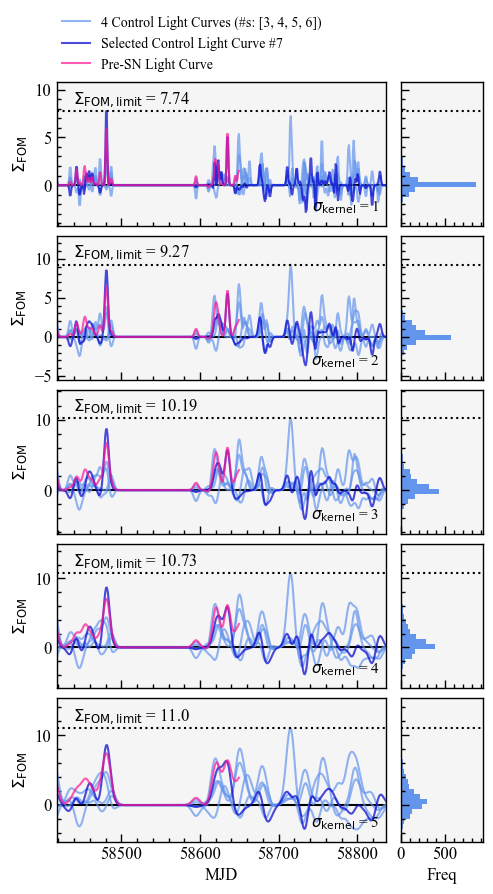

In [10]:
# ==== User Settings ====

# Enter the index of the control light curve to highlight:
SELECT_CONTROL_INDEX = 7

# =======================

fig = p.plot_fom(
    avg_sn, 
    all_fom_dict,
    SIGMA_KERNS, 
    SELECT_CONTROL_INDEX, 
    hexstring_to_int(config['averaging']['flag']),
    fom_limits={sigma_kern: fom_limits[1] for sigma_kern, fom_limits in prelim_fom_limit_ranges.items()},
    save=SAVE_PLOTS
)

### Calculate the best detection limits $\Sigma_{\text{FOM, limit}}$

We use the starting range of valid detection limits $\Sigma_{\text{FOM, limit}}$ and their corresponding contamination values to calculate the detection limit with the ideal contamination. Below, we allow the user to select the desired measure of contamination (i.e., the number of positive control light curves). 

We iterate for n_steps steps. If we have a starting range of detection limits $\Sigma_{\text{FOM, limit}}$ from $a$ to $b$ and iterate for $n$ steps, we obtain the detection limit with the desired contamination with an accuracy of $\frac{b-a}{2^n}$.

In [11]:
# ==== User Settings ====

# Enter the target contamination
# (i.e. the target number of positive control light curves for a given FOM limit):
TARGET_VALUE = 2

# Enter the maximum number of iterations for refining FOM limits:
N_STEPS = 15

# =======================

fom_limits = contam.calculate(
    avg_sn, 
    prelim_fom_limit_ranges, 
    included_mjd_ranges,
    SIGMA_KERNS,
    target_value=TARGET_VALUE,
    n_steps=N_STEPS,
    verbose=True
)
# print(contam)
print(f"Best FOM limits for sigma_kerns: {fom_limits}")

Preliminary contamination table: 
   sigma_kern  fom_limit  n_falsepos  n_pos_controls  pct_pos_controls  n_falsepos_00  n_falsepos_03  n_falsepos_04  n_falsepos_05  n_falsepos_06  n_falsepos_07
0           1       0.00          86               5             71.43              7             17             16             17             20             16
1           1       7.74           0               0              0.00              0              0              0              0              0              0
2           2       0.00          65               5             71.43              3             13             14             11             15             12
3           2       9.27           0               0              0.00              0              0              0              0              0              0
4           3       0.00          49               5             71.43              2             10             11              5             11             12


### Plot the best detection limits $\Sigma_{\text{FOM, limit}}$

Applying rolling sum of sigma_kern=1 to all light curves (using only pre-MJD0 MJDs for SN light curve)...
Applying rolling sum of sigma_kern=2 to all light curves (using only pre-MJD0 MJDs for SN light curve)...
Applying rolling sum of sigma_kern=3 to all light curves (using only pre-MJD0 MJDs for SN light curve)...
Applying rolling sum of sigma_kern=4 to all light curves (using only pre-MJD0 MJDs for SN light curve)...
Applying rolling sum of sigma_kern=5 to all light curves (using only pre-MJD0 MJDs for SN light curve)...


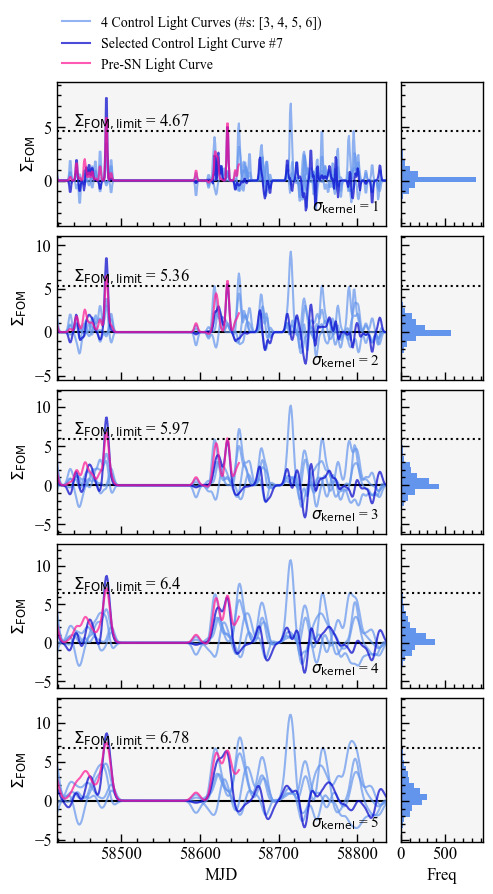

In [12]:
fig = p.plot_fom(
    avg_sn, 
    all_fom_dict,
    SIGMA_KERNS, 
    SELECT_CONTROL_INDEX, 
    hexstring_to_int(config['averaging']['flag']),
    fom_limits=fom_limits,
    save=SAVE_PLOTS
)

- 400-day window between t1 and t2
- Zac will give me the SN with power law and subtraction, then can run that through the analysis
- TESS -> smaller bin size 
- Ask Zac about sigma kernels


- Flatten FOM limits list returned from calculate()?
- All front-facing functions should have extensive documentation